# Aufgabe 1



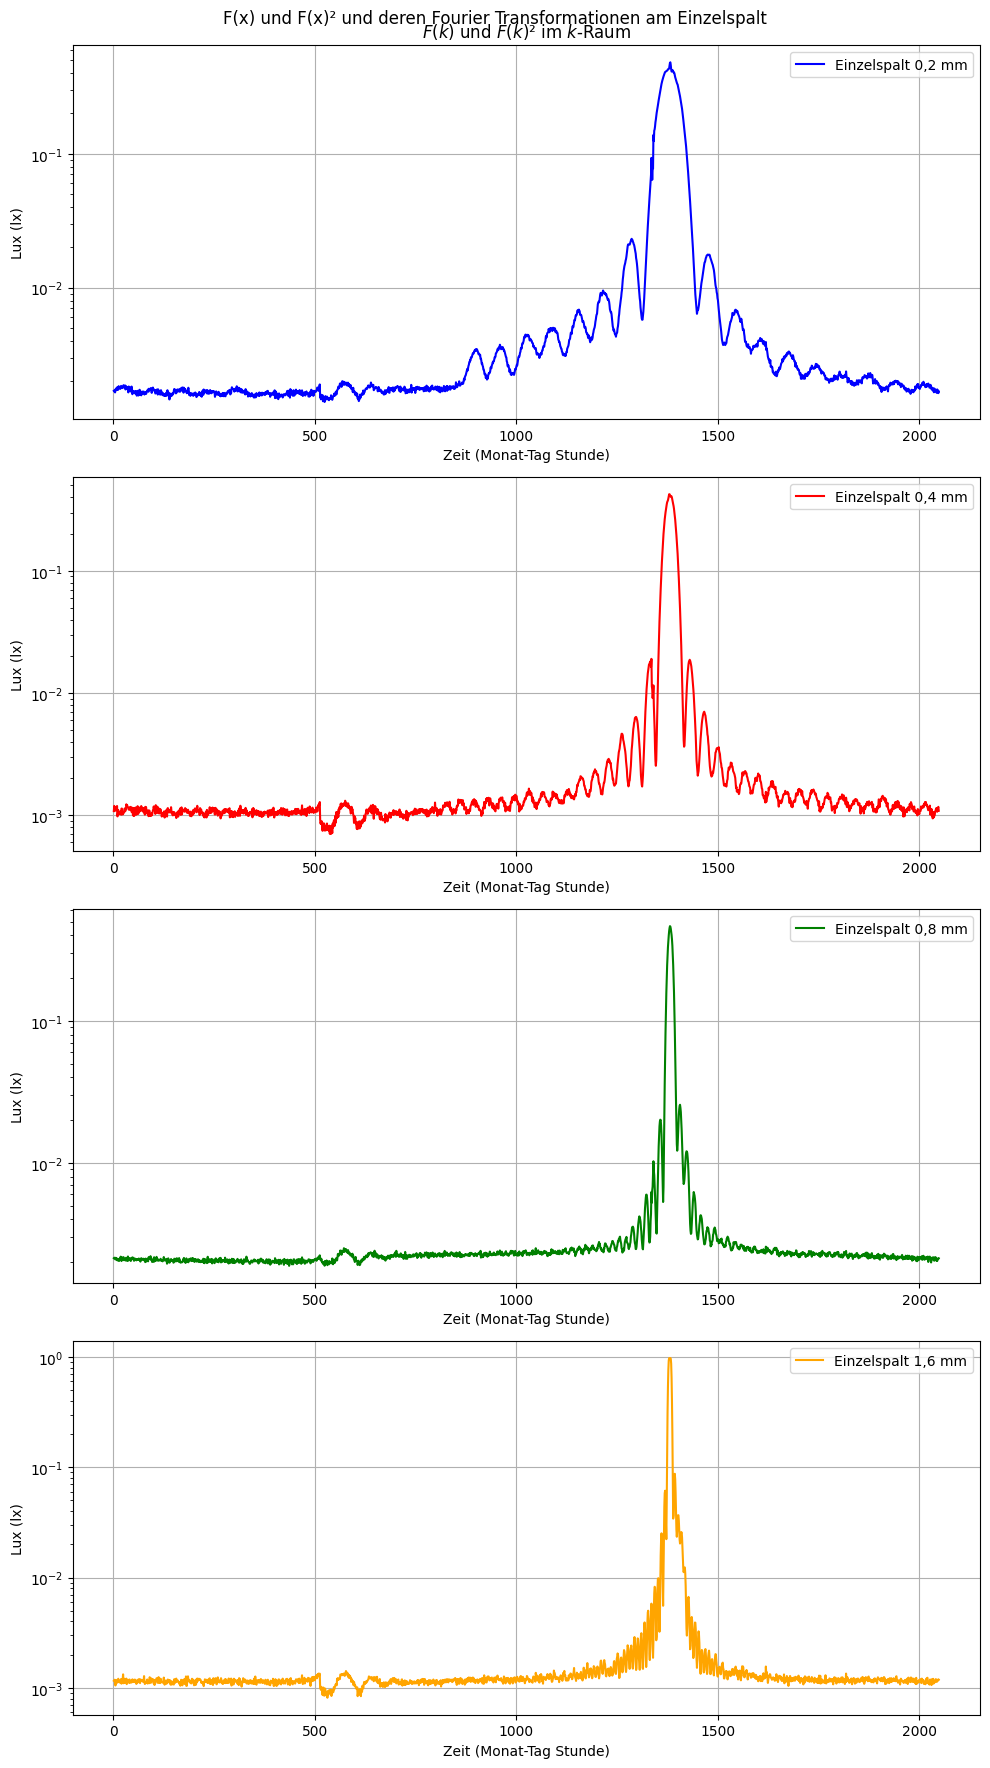

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# CSV einlesen
df = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv")
dt = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv")
dn = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv")
dm = pd.read_csv("O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv")


# Plot für a_x
fig, axs = plt.subplots(4, 1, figsize=(10, 18))
fig.suptitle("F(x) und F(x)² und deren Fourier Transformationen am Einzelspalt")

axs[0].plot(df['x'], df['y'], label="Einzelspalt 0,2 mm", color="blue")
axs[0].set_yscale("log")
axs[0].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[0].set_ylabel("Lux (lx)")
axs[0].set_title("$F(k)$ und $F(k)²$ im $k$-Raum")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(dt['x'], dt['y'], label="Einzelspalt 0,4 mm", color="red")
axs[1].set_yscale("log")
axs[1].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[1].set_ylabel("Lux (lx)")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(dn['x'], dn['y'], label="Einzelspalt 0,8 mm", color="green")
axs[2].set_yscale("log")
axs[2].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[2].set_ylabel("Lux (lx)")
axs[2].grid(True)
axs[2].legend()

axs[3].plot(dm['x'], dm['y'], label="Einzelspalt 1,6 mm", color="orange")
axs[3].set_yscale("log")
axs[3].set_xlabel("Zeit (Monat-Tag Stunde)")
axs[3].set_ylabel("Lux (lx)")
axs[3].grid(True)
axs[3].legend()

fig.tight_layout()
plt.show()

## Fourier Transformation

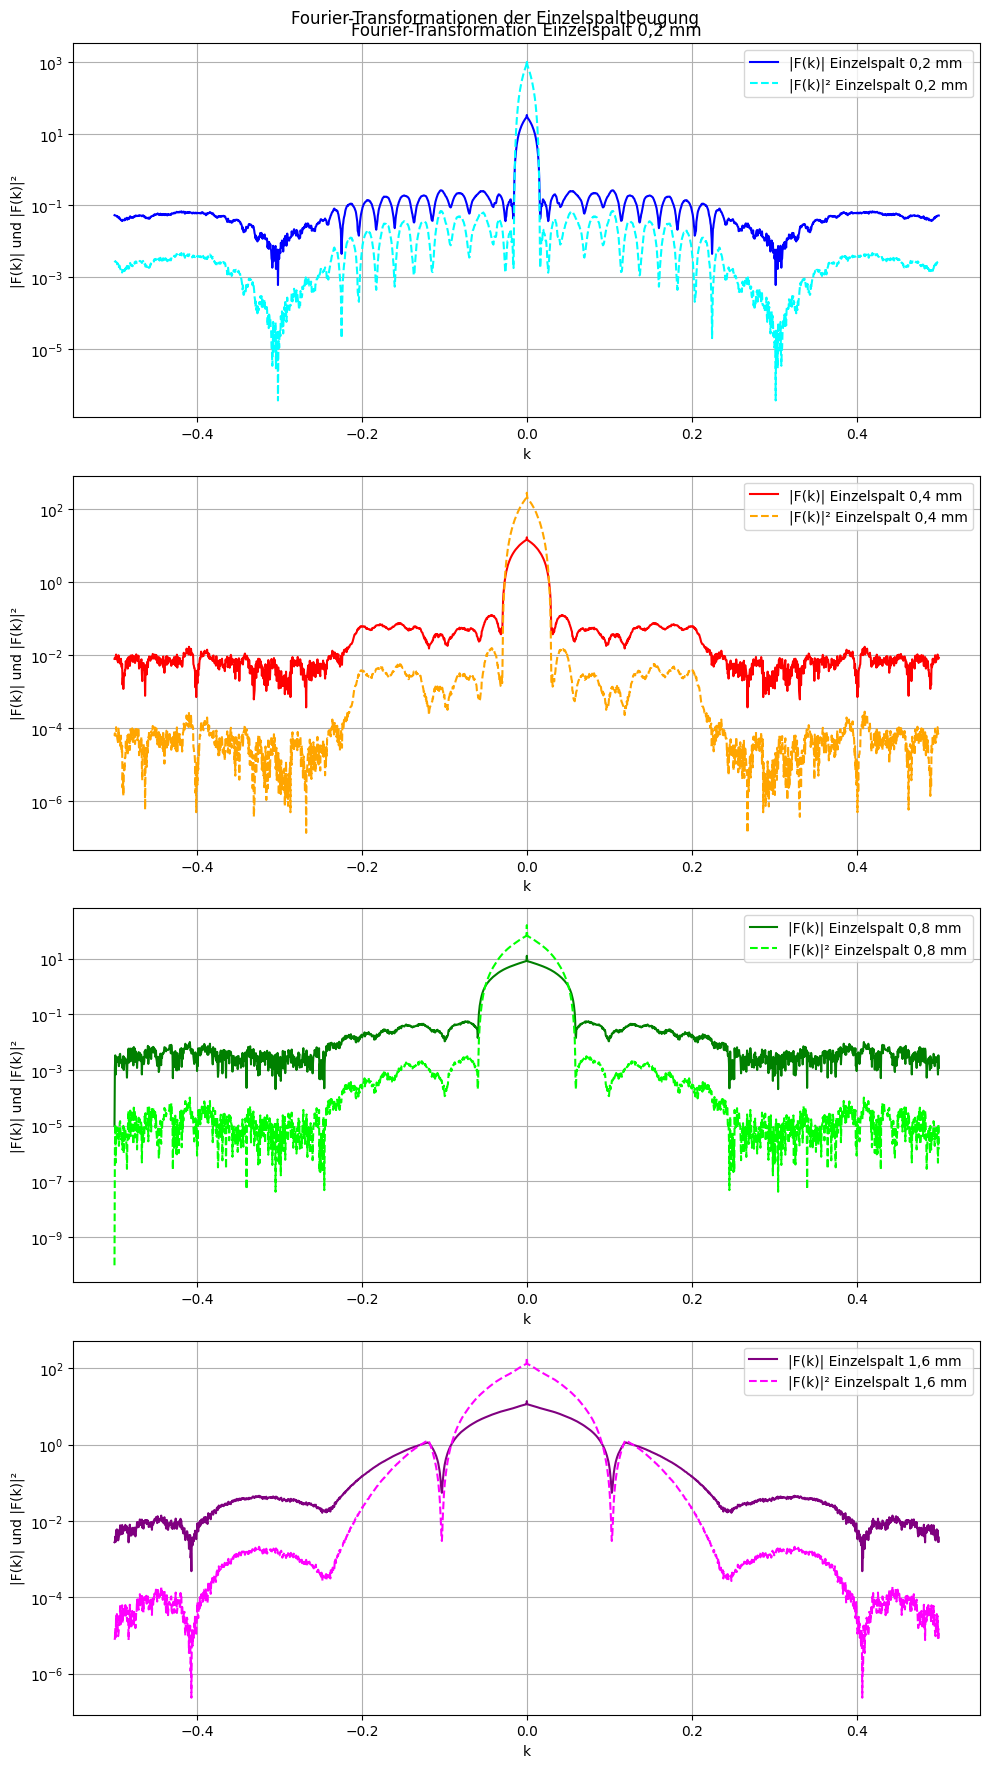

In [19]:
# Verwende bereits importierte numpy, matplotlib und die DataFrames (df, dt, dn, dm)
# (Die CSVs und Importe wurden bereits in einer früheren Zelle gemacht.)

# Fourier Transformationen mit numpy.fft (empfohlen gegenüber scipy.fftpack)
y_df = df['y'].values.astype(float)
y_dt = dt['y'].values.astype(float)
y_dn = dn['y'].values.astype(float)
y_dm = dm['y'].values.astype(float)

# Abstand in x (falls x regelmäßig, ansonsten mittlerer Abstand verwenden)
dx_df = np.mean(np.diff(df['x'].values))
dx_dt = np.mean(np.diff(dt['x'].values))
dx_dn = np.mean(np.diff(dn['x'].values))
dx_dm = np.mean(np.diff(dm['x'].values))

F_df = np.fft.fft(y_df)
F_dt = np.fft.fft(y_dt)
F_dn = np.fft.fft(y_dn)
F_dm = np.fft.fft(y_dm)

F2_df = np.abs(F_df)**2
F2_dt = np.abs(F_dt)**2
F2_dn = np.abs(F_dn)**2
F2_dm = np.abs(F_dm)**2

k_df = np.fft.fftfreq(len(y_df), d=dx_df)
k_dt = np.fft.fftfreq(len(y_dt), d=dx_dt)
k_dn = np.fft.fftfreq(len(y_dn), d=dx_dn)
k_dm = np.fft.fftfreq(len(y_dm), d=dx_dm)

# Für bessere Visualisierung: Frequenzen zentrieren (optional)
k_df_s = np.fft.fftshift(k_df)
k_dt_s = np.fft.fftshift(k_dt)
k_dn_s = np.fft.fftshift(k_dn)
k_dm_s = np.fft.fftshift(k_dm)

F_df_s = np.fft.fftshift(np.abs(F_df))
F_dt_s = np.fft.fftshift(np.abs(F_dt))
F_dn_s = np.fft.fftshift(np.abs(F_dn))
F_dm_s = np.fft.fftshift(np.abs(F_dm))

F2_df_s = np.fft.fftshift(F2_df)
F2_dt_s = np.fft.fftshift(F2_dt)
F2_dn_s = np.fft.fftshift(F2_dn)
F2_dm_s = np.fft.fftshift(F2_dm)

# Benutze anderen Namen für Achsen-Array, um keine früheren axs zu überschreiben
fig_ft, axs_ft = plt.subplots(4, 1, figsize=(10, 18))
fig_ft.suptitle("Fourier-Transformationen der Einzelspaltbeugung")

axs_ft[0].plot(k_df_s, F_df_s, label="|F(k)| Einzelspalt 0,2 mm", color="blue")
axs_ft[0].plot(k_df_s, F2_df_s, label="|F(k)|² Einzelspalt 0,2 mm", color="cyan", linestyle="--")
axs_ft[0].set_yscale("log")
axs_ft[0].set_xlabel("k")
axs_ft[0].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[0].set_title("Fourier-Transformation Einzelspalt 0,2 mm")
axs_ft[0].grid(True)
axs_ft[0].legend()

axs_ft[1].plot(k_dt_s, F_dt_s, label="|F(k)| Einzelspalt 0,4 mm", color="red")
axs_ft[1].plot(k_dt_s, F2_dt_s, label="|F(k)|² Einzelspalt 0,4 mm", color="orange", linestyle="--")
axs_ft[1].set_yscale("log")
axs_ft[1].set_xlabel("k")
axs_ft[1].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[1].grid(True)
axs_ft[1].legend()

axs_ft[2].plot(k_dn_s, F_dn_s, label="|F(k)| Einzelspalt 0,8 mm", color="green")
axs_ft[2].plot(k_dn_s, F2_dn_s, label="|F(k)|² Einzelspalt 0,8 mm", color="lime", linestyle="--")
axs_ft[2].set_yscale("log")
axs_ft[2].set_xlabel("k")
axs_ft[2].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[2].grid(True)
axs_ft[2].legend()

axs_ft[3].plot(k_dm_s, F_dm_s, label="|F(k)| Einzelspalt 1,6 mm", color="purple")
axs_ft[3].plot(k_dm_s, F2_dm_s, label="|F(k)|² Einzelspalt 1,6 mm", color="magenta", linestyle="--")
axs_ft[3].set_yscale("log")
axs_ft[3].set_xlabel("k")
axs_ft[3].set_ylabel("|F(k)| und |F(k)|²")
axs_ft[3].grid(True)
axs_ft[3].legend()

fig_ft.tight_layout()
plt.show()




=== Auswertung für Einzelspalt-Daten 1 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1380.0 px
Pixelposition 1. Minimum links     : 1312.0 px
Pixelposition 1. Minimum rechts    : 1450.0 px
Delta_px links                     : 68.0 px
Delta_px rechts                    : 70.0 px
gemitteltes Delta_px               : 69.0 px
Abstand x1 (physikalisch)          : 7.590e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 2.528e-04 m
                                   = 252.81 µm
-------------------------------------------------


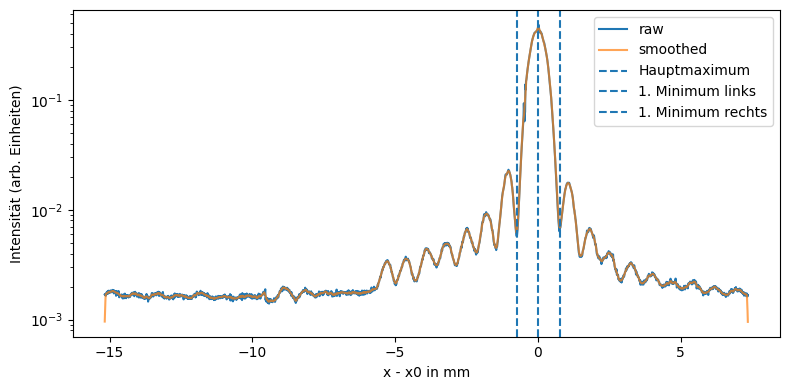


=== Auswertung für Einzelspalt-Daten 2 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1381.0 px
Pixelposition 1. Minimum links     : 1346.0 px
Pixelposition 1. Minimum rechts    : 1417.0 px
Delta_px links                     : 35.0 px
Delta_px rechts                    : 36.0 px
gemitteltes Delta_px               : 35.5 px
Abstand x1 (physikalisch)          : 3.905e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 4.914e-04 m
                                   = 491.37 µm
-------------------------------------------------


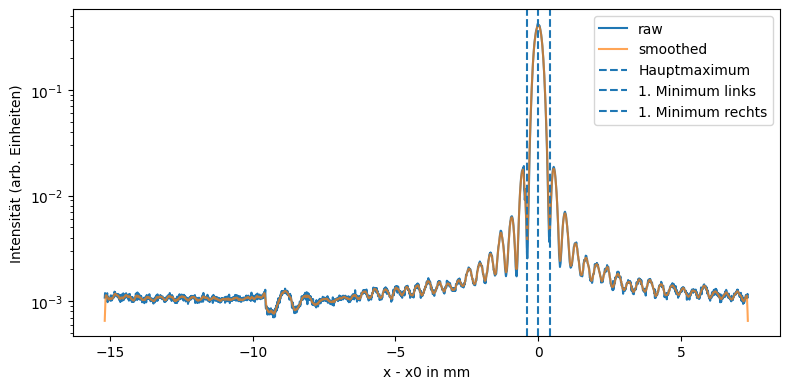


=== Auswertung für Einzelspalt-Daten 3 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1382.0 px
Pixelposition 1. Minimum links     : 1363.0 px
Pixelposition 1. Minimum rechts    : 1400.0 px
Delta_px links                     : 19.0 px
Delta_px rechts                    : 18.0 px
gemitteltes Delta_px               : 18.5 px
Abstand x1 (physikalisch)          : 2.035e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 9.429e-04 m
                                   = 942.91 µm
-------------------------------------------------


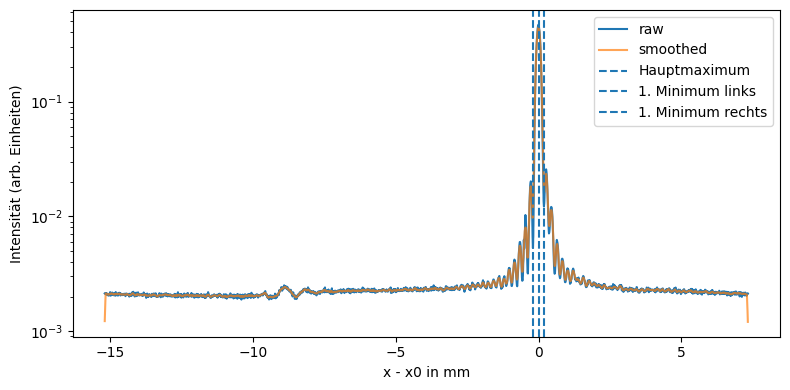


=== Auswertung für Einzelspalt-Daten 4 ===
-------------------------------------------------
Pixelposition Hauptmaximum         : 1381.0 px
Pixelposition 1. Minimum links     : 1362.0 px
Pixelposition 1. Minimum rechts    : 1392.0 px
Delta_px links                     : 19.0 px
Delta_px rechts                    : 11.0 px
gemitteltes Delta_px               : 15.0 px
Abstand x1 (physikalisch)          : 1.650e-04 m
-------------------------------------------------
Spaltbreite b (nur 1. Ordnung)     : 1.163e-03 m
                                   = 1162.92 µm
-------------------------------------------------


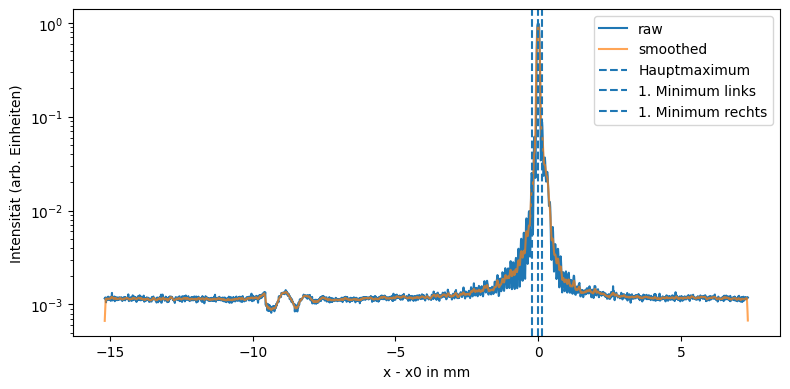

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ---------------------------------------------------
# 1) EXPERIMENTPARAMETER
# ---------------------------------------------------
lambda_ = 636e-9      # Wellenlänge in m (636 nm)
f = 0.3017            # Brennweite der Linse in m -> HIER euren Wert eintragen!
pixel_size = 11e-6     # Pixelgröße in m (z.B. 7 µm)

einzelspalt_0_2 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung02mm.csv"
einzelspalt_0_4 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung04mm.csv"
einzelspalt_0_8 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung08mm.csv"
einzelspalt_1_6 = "O17 Messdaten/Aufgabe 1/EinzelspaltBeugung16mm.csv"

# ---------------------------------------------------
# 2) Daten einlesen
# ---------------------------------------------------
df_1 = pd.read_csv(einzelspalt_0_2)
df_2 = pd.read_csv(einzelspalt_0_4)
df_3 = pd.read_csv(einzelspalt_0_8)
df_4 = pd.read_csv(einzelspalt_1_6)
for i, df in enumerate([df_1, df_2, df_3, df_4], start=1):
    print(f"\n=== Auswertung für Einzelspalt-Daten {i} ===")
    x_pixels = df["x"].values          # Pixelindizes (1..N)
    I_raw = df["y"].values.astype(float)

    # ---------------------------------------------------
    # 3) Intensität leicht glätten
    # ---------------------------------------------------
    window = 7
    kernel = np.ones(window) / window
    I = np.convolve(I_raw, kernel, mode="same")

    # ---------------------------------------------------
    # 4) Hauptmaximum finden
    # ---------------------------------------------------
    peaks, _ = find_peaks(I)
    idx_max_main = peaks[np.argmax(I[peaks])]   # Index des höchsten Peaks
    x0_px = x_pixels[idx_max_main]              # Pixelposition des Hauptmaximums

    # ---------------------------------------------------
    # 5) Minima 1. Ordnung links und rechts vom Hauptmaximum
    #    -> Minima sind Peaks in -I
    # ---------------------------------------------------
    minima_idx, _ = find_peaks(-I)

    # Minima links/rechts vom Hauptmaximum
    minima_left = minima_idx[minima_idx < idx_max_main]
    minima_right = minima_idx[minima_idx > idx_max_main]

    # nächstgelegenes Minimum links/rechts = 1. Ordnung
    idx_min_left = minima_left[-1]    # größter Index < idx_max_main
    idx_min_right = minima_right[0]   # kleinster Index > idx_max_main

    x_left_px = x_pixels[idx_min_left]
    x_right_px = x_pixels[idx_min_right]

    # Pixelabstände vom Hauptmaximum
    delta_px_left = abs(x_left_px - x0_px)
    delta_px_right = abs(x_right_px - x0_px)

    # x1 als Mittelwert der beiden Seiten (sollten ideal gleich sein)
    delta_px = 0.5 * (delta_px_left + delta_px_right)
    x1_phys = delta_px * pixel_size   # Abstand 1. Minimum in Metern

    # ---------------------------------------------------
    # 6) Spaltbreite b aus Fraunhofer-Bedingung
    #    b * sin(alpha_1) = lambda,  sin(alpha_1) ≈ x1 / f
    #    -> b = lambda * f / x1
    # ---------------------------------------------------
    b = lambda_ * f / x1_phys

    print("-------------------------------------------------")
    print(f"Pixelposition Hauptmaximum         : {x0_px:.1f} px")
    print(f"Pixelposition 1. Minimum links     : {x_left_px:.1f} px")
    print(f"Pixelposition 1. Minimum rechts    : {x_right_px:.1f} px")
    print(f"Delta_px links                     : {delta_px_left:.1f} px")
    print(f"Delta_px rechts                    : {delta_px_right:.1f} px")
    print(f"gemitteltes Delta_px               : {delta_px:.1f} px")
    print(f"Abstand x1 (physikalisch)          : {x1_phys:.3e} m")
    print("-------------------------------------------------")
    print(f"Spaltbreite b (nur 1. Ordnung)     : {b:.3e} m")
    print(f"                                   = {b*1e6:.2f} µm")
    print("-------------------------------------------------")

    # ---------------------------------------------------
    # 7) Plot zur Kontrolle
    # ---------------------------------------------------
    # x-Achse um das Hauptmaximum zentrieren (in mm)
    x_rel_m = (x_pixels - x0_px) * pixel_size

    plt.figure(figsize=(8,4))
    plt.plot(x_rel_m * 1e3, I_raw, label="raw")
    plt.plot(x_rel_m * 1e3, I, label="smoothed", alpha=0.7)

    plt.axvline(0.0, linestyle="--", label="Hauptmaximum")
    plt.axvline(x_rel_m[idx_min_left] * 1e3, linestyle="--", label="1. Minimum links")
    plt.axvline(x_rel_m[idx_min_right] * 1e3, linestyle="--", label="1. Minimum rechts")

    plt.yscale("log")
    plt.xlabel("x - x0 in mm")
    plt.ylabel("Intensität (arb. Einheiten)")
    plt.legend()
    plt.tight_layout()
    plt.show()
